# 🛒 SmartPantry AI — Complete Notebook (Sprint 1 + Sprint 2)
**Portfolio Project | Agentic AI + Advanced Analytics**

### How to use
1. In Cell 1 below, change `GITHUB_USER` to your GitHub username (edit in Colab, not on GitHub)
2. Runtime → Run all
3. When done: File → Save a copy in GitHub → select repo → commit

### Session restart
Just reopen the Colab URL and Runtime → Run all again. Takes 1-2 mins. Nothing is lost.

---

## Cell 1 — Setup: Clone Repo + Imports

In [44]:
import os, subprocess, json, random, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
today = datetime.today().date()

# ── UPDATE THIS LINE ONLY ─────────────────────────────────────────────────────
GITHUB_USER = 'data-analytics-leader-kunjanmehta'
# ─────────────────────────────────────────────────────────────────────────────

GITHUB_REPO = 'SmartPantry-AI'
REPO_DIR    = f'/content/{GITHUB_REPO}'
DATA_DIR    = f'{REPO_DIR}/data'
OUTPUT_DIR  = f'{REPO_DIR}/outputs'

if os.path.exists(REPO_DIR):
    subprocess.run('git pull', shell=True, cwd=REPO_DIR)
    print('Repo pulled ✓')
else:
    subprocess.run(f'git clone https://github.com/{GITHUB_USER}/{GITHUB_REPO}.git {REPO_DIR}', shell=True)
    print('Repo cloned ✓')

os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Today      : {today}')
print(f'Data dir   : {DATA_DIR}')
print(f'Output dir : {OUTPUT_DIR}')

Repo pulled ✓
Today      : 2026-07-02
Data dir   : /content/SmartPantry-AI/data
Output dir : /content/SmartPantry-AI/outputs


## Cell 2 — Family Profile
> Customise this to match your actual family.

In [45]:
family_profile = {
    'family_id': 'HOME_001',
    'name': 'My Home',
    'members': [
        {'name': 'Adult 1', 'age_group': 'adult', 'diet': 'vegetarian'},
        {'name': 'Adult 2', 'age_group': 'adult', 'diet': 'non-vegetarian'},
        {'name': 'Child 1', 'age_group': 'child', 'diet': 'vegetarian'},
        {'name': 'Child 2', 'age_group': 'child', 'diet': 'vegetarian'},
    ],
    'total_members': 4,
    'adults': 2,
    'children': 2,
    'monthly_grocery_budget_inr': 12000,
    'preferred_order_day': 'Sunday',
    'order_platform': 'Zepto/Blinkit',
    'city': 'Bengaluru'
}
with open(f'{DATA_DIR}/family_profile.json', 'w') as f:
    json.dump(family_profile, f, indent=2)
print(f'Family : {family_profile["total_members"]} members | Budget Rs.{family_profile["monthly_grocery_budget_inr"]:,}/mo')
print(f'Saved  : {DATA_DIR}/family_profile.json')

Family : 4 members | Budget Rs.12,000/mo
Saved  : /content/SmartPantry-AI/data/family_profile.json


## Cell 3 — Item Master (40 items, 13 categories)

In [46]:
items = [
    ('Rice (Basmati)',     'Grains',     'kg',     5.0,  1.5, 1, 120, 365, False, 'steady'),
    ('Wheat Atta',        'Grains',     'kg',     4.0,  1.0, 1,  55, 180, False, 'steady'),
    ('Poha',              'Grains',     'kg',     0.5,  0.2, 1,  50, 180, False, 'steady'),
    ('Oats',              'Grains',     'kg',     0.5,  0.2, 1,  80, 180, False, 'steady'),
    ('Pasta',             'Grains',     'kg',     0.5,  0.2, 1,  80, 365, False, 'occasional'),
    ('Toor Dal',          'Pulses',     'kg',     1.5,  0.4, 1,  95, 365, False, 'steady'),
    ('Chana Dal',         'Pulses',     'kg',     0.5,  0.2, 1,  90, 365, False, 'steady'),
    ('Moong Dal',         'Pulses',     'kg',     0.5,  0.2, 1,  90, 365, False, 'steady'),
    ('Rajma',             'Pulses',     'kg',     0.3,  0.1, 1,  85, 365, False, 'occasional'),
    ('Milk',              'Dairy',      'litre', 15.0,  3.0, 0,  64,   2, True,  'daily'),
    ('Curd',              'Dairy',      'kg',     2.0,  0.5, 0,  40,   7, True,  'steady'),
    ('Paneer',            'Dairy',      'kg',     0.5,  0.2, 0, 320,   7, True,  'occasional'),
    ('Butter',            'Dairy',      'gm',   200.0, 50.0, 1, 0.7,  30, True,  'steady'),
    ('Eggs',              'Protein',    'pcs',   24.0,  6.0, 0,   8,  21, True,  'steady'),
    ('Chicken',           'Protein',    'kg',     1.5,  0.5, 0, 180,   2, True,  'occasional'),
    ('Onion',             'Vegetables', 'kg',     3.0,  0.8, 0,  30,  30, False, 'steady'),
    ('Tomato',            'Vegetables', 'kg',     2.0,  0.5, 0,  40,   7, True,  'steady'),
    ('Potato',            'Vegetables', 'kg',     2.0,  0.5, 0,  25,  30, False, 'steady'),
    ('Garlic',            'Vegetables', 'gm',   200.0, 50.0, 0, 0.2,  30, False, 'steady'),
    ('Ginger',            'Vegetables', 'gm',   100.0, 30.0, 0, 0.2,  14, True,  'steady'),
    ('Spinach',           'Vegetables', 'bundle', 2.0,  1.0, 0,  30,   3, True,  'weekly'),
    ('Capsicum',          'Vegetables', 'pcs',    4.0,  1.0, 0,  20,   7, True,  'weekly'),
    ('Sunflower Oil',     'Oils & Fats','litre',  2.0,  0.5, 1, 140, 365, False, 'steady'),
    ('Mustard Oil',       'Oils & Fats','litre',  0.5,  0.2, 1, 130, 365, False, 'occasional'),
    ('Ghee',              'Oils & Fats','gm',   250.0, 80.0, 1, 1.1, 365, False, 'steady'),
    ('Salt',              'Spices',     'kg',     0.5,  0.2, 2,  20, 730, False, 'slow'),
    ('Turmeric',          'Spices',     'gm',   100.0, 30.0, 2, 0.14,365, False, 'slow'),
    ('Red Chilli Powder', 'Spices',     'gm',   100.0, 30.0, 2, 0.2, 365, False, 'slow'),
    ('Coriander Powder',  'Spices',     'gm',   100.0, 30.0, 2, 0.15,365, False, 'slow'),
    ('Cumin Seeds',       'Spices',     'gm',   100.0, 30.0, 2, 0.25,365, False, 'slow'),
    ('Garam Masala',      'Spices',     'gm',    50.0, 15.0, 2, 0.9, 365, False, 'slow'),
    ('Tea',               'Beverages',  'gm',   500.0,150.0, 1, 0.8, 365, False, 'steady'),
    ('Coffee',            'Beverages',  'gm',   200.0, 60.0, 1, 2.25,365, False, 'steady'),
    ('Sugar',             'Sweeteners', 'kg',     1.5,  0.4, 1,  42, 365, False, 'steady'),
    ('Jaggery',           'Sweeteners', 'gm',   200.0, 80.0, 1, 0.15,180, False, 'occasional'),
    ('Bread',             'Bakery',     'loaf',   2.0,  1.0, 0,  45,   7, True,  'weekly'),
    ('Biscuits',          'Snacks',     'pack',   3.0,  1.0, 1,  35, 180, False, 'steady'),
    ('Maggi Noodles',     'Snacks',     'pack',   4.0,  1.0, 1,  14, 365, False, 'occasional'),
    ('Coconut Milk',      'Canned',     'tin',    2.0,  0.5, 2,  55, 730, False, 'occasional'),
    ('Tomato Ketchup',    'Condiments', 'gm',   500.0,100.0, 1, 0.16,365, False, 'slow'),
]
cols = ['item_name','category','unit','monthly_consumption_4pax','reorder_threshold',
        'lead_time_days','price_inr_per_unit','shelf_life_days','is_perishable','consumption_pattern']
df_master = pd.DataFrame(items, columns=cols)
df_master['item_id'] = ['ITEM_' + str(i+1).zfill(3) for i in range(len(df_master))]
df_master['daily_consumption_rate'] = (df_master['monthly_consumption_4pax'] / 30).round(4)
df_master.to_csv(f'{DATA_DIR}/item_master.csv', index=False)
print(f'Item master: {len(df_master)} items | {df_master["category"].nunique()} categories')
print(df_master.groupby('category')['item_name'].count().sort_values(ascending=False).to_string())
print(f'Saved: {DATA_DIR}/item_master.csv')

Item master: 40 items | 13 categories
category
Vegetables     7
Spices         6
Grains         5
Pulses         4
Dairy          4
Oils & Fats    3
Protein        2
Snacks         2
Beverages      2
Sweeteners     2
Condiments     1
Bakery         1
Canned         1
Saved: /content/SmartPantry-AI/data/item_master.csv


## Cell 4 — Pantry Snapshot

In [47]:
def simulate_current_stock(row):
    max_stock = row['monthly_consumption_4pax'] * 1.5
    fracs = {'daily':(.05,.25),'weekly':(.1,.5),'steady':(.15,.85),'occasional':(.2,1.0),'slow':(.4,1.2)}
    lo, hi = fracs.get(row['consumption_pattern'], (.3,.7))
    return round(max_stock * np.random.uniform(lo, hi), 2)

df_pantry = df_master.copy()
df_pantry['current_stock'] = df_pantry.apply(simulate_current_stock, axis=1)
df_pantry['last_restocked_date'] = [str(today - timedelta(days=random.randint(0,20))) for _ in range(len(df_pantry))]
df_pantry['days_to_empty'] = (df_pantry['current_stock'] / df_pantry['daily_consumption_rate']).clip(upper=60).round(1)
df_pantry['stock_status'] = pd.cut(df_pantry['days_to_empty'], bins=[-1,3,7,14,60],
    labels=['CRITICAL','LOW','MODERATE','SUFFICIENT'])
df_pantry['reorder_needed']    = df_pantry['current_stock'] <= df_pantry['reorder_threshold']
df_pantry['snapshot_date']     = str(today)
df_pantry['monthly_spend_inr'] = (df_pantry['monthly_consumption_4pax'] * df_pantry['price_inr_per_unit']).round(0)
df_pantry.to_csv(f'{DATA_DIR}/pantry_snapshot.csv', index=False)

sc = df_pantry['stock_status'].value_counts()
print('Pantry Snapshot:')
for s,e in [('CRITICAL','🔴'),('LOW','🟠'),('MODERATE','🟡'),('SUFFICIENT','🟢')]:
    print(f'  {e} {s}: {sc.get(s,0)} items')
print(f'  Reorder needed    : {df_pantry["reorder_needed"].sum()} items')
print(f'  Est. monthly spend: Rs.{df_pantry["monthly_spend_inr"].sum():,.0f}')
print(f'Saved: {DATA_DIR}/pantry_snapshot.csv')

Pantry Snapshot:
  🔴 CRITICAL: 0 items
  🟠 LOW: 1 items
  🟡 MODERATE: 9 items
  🟢 SUFFICIENT: 30 items
  Reorder needed    : 4 items
  Est. monthly spend: Rs.5,538
Saved: /content/SmartPantry-AI/data/pantry_snapshot.csv


## Cell 5 — Weekly Menu Plan

In [48]:
menu_plan = [
    {'day':'Monday',    'meal':'Breakfast','dish':'Poha',
     'ingredients':{'Poha':.2,'Onion':.1,'Mustard Oil':.02,'Cumin Seeds':.005,'Salt':.005,'Turmeric':.002}},
    {'day':'Monday',    'meal':'Lunch',    'dish':'Dal Tadka + Rice',
     'ingredients':{'Toor Dal':.15,'Rice (Basmati)':.3,'Onion':.1,'Tomato':.1,'Ghee':.02,'Cumin Seeds':.005,'Turmeric':.003,'Salt':.005}},
    {'day':'Monday',    'meal':'Dinner',   'dish':'Roti + Paneer Curry',
     'ingredients':{'Wheat Atta':.3,'Paneer':.2,'Tomato':.15,'Onion':.1,'Sunflower Oil':.03,'Garam Masala':.005,'Salt':.005}},
    {'day':'Tuesday',   'meal':'Breakfast','dish':'Oats Porridge',
     'ingredients':{'Oats':.15,'Milk':.3,'Sugar':.03,'Jaggery':.02}},
    {'day':'Tuesday',   'meal':'Lunch',    'dish':'Rajma Chawal',
     'ingredients':{'Rajma':.15,'Rice (Basmati)':.3,'Onion':.15,'Tomato':.15,'Sunflower Oil':.03,'Cumin Seeds':.005,'Garam Masala':.005}},
    {'day':'Tuesday',   'meal':'Dinner',   'dish':'Roti + Egg Curry',
     'ingredients':{'Wheat Atta':.3,'Eggs':2.,'Onion':.1,'Tomato':.1,'Sunflower Oil':.03,'Red Chilli Powder':.005,'Salt':.005}},
    {'day':'Wednesday', 'meal':'Breakfast','dish':'Bread Butter + Eggs',
     'ingredients':{'Bread':.5,'Butter':.03,'Eggs':2.}},
    {'day':'Wednesday', 'meal':'Lunch',    'dish':'Palak Dal + Rice',
     'ingredients':{'Moong Dal':.12,'Spinach':.3,'Rice (Basmati)':.3,'Ghee':.02,'Garlic':.02,'Cumin Seeds':.005,'Turmeric':.003}},
    {'day':'Wednesday', 'meal':'Dinner',   'dish':'Chicken Curry + Roti',
     'ingredients':{'Chicken':.5,'Wheat Atta':.3,'Onion':.2,'Tomato':.15,'Ginger':.02,'Garlic':.02,'Sunflower Oil':.04,'Garam Masala':.008,'Salt':.005}},
    {'day':'Thursday',  'meal':'Breakfast','dish':'Poha + Curd',
     'ingredients':{'Poha':.2,'Curd':.1,'Salt':.003}},
    {'day':'Thursday',  'meal':'Lunch',    'dish':'Chana Dal + Rice',
     'ingredients':{'Chana Dal':.15,'Rice (Basmati)':.3,'Tomato':.1,'Onion':.1,'Sunflower Oil':.025,'Coriander Powder':.005,'Turmeric':.003}},
    {'day':'Thursday',  'meal':'Dinner',   'dish':'Pasta Arrabiata',
     'ingredients':{'Pasta':.25,'Tomato':.2,'Capsicum':1.,'Garlic':.015,'Sunflower Oil':.03,'Red Chilli Powder':.005,'Salt':.005}},
    {'day':'Friday',    'meal':'Breakfast','dish':'Oats + Milk',
     'ingredients':{'Oats':.15,'Milk':.3,'Sugar':.02}},
    {'day':'Friday',    'meal':'Lunch',    'dish':'Aloo Sabzi + Roti',
     'ingredients':{'Potato':.3,'Wheat Atta':.3,'Onion':.1,'Turmeric':.003,'Cumin Seeds':.005,'Salt':.005,'Sunflower Oil':.025}},
    {'day':'Friday',    'meal':'Dinner',   'dish':'Maggi + Egg',
     'ingredients':{'Maggi Noodles':2.,'Eggs':2.,'Onion':.05,'Tomato Ketchup':.03}},
    {'day':'Saturday',  'meal':'Breakfast','dish':'Poori + Aloo',
     'ingredients':{'Wheat Atta':.4,'Potato':.2,'Sunflower Oil':.1,'Salt':.005,'Cumin Seeds':.003}},
    {'day':'Saturday',  'meal':'Lunch',    'dish':'Chicken Biryani',
     'ingredients':{'Rice (Basmati)':.5,'Chicken':.5,'Onion':.3,'Tomato':.2,'Ghee':.04,'Ginger':.02,'Garlic':.02,'Garam Masala':.01,'Salt':.005}},
    {'day':'Saturday',  'meal':'Dinner',   'dish':'Paneer Tikka + Roti',
     'ingredients':{'Paneer':.25,'Wheat Atta':.3,'Capsicum':1.,'Curd':.1,'Red Chilli Powder':.005,'Salt':.003}},
    {'day':'Sunday',    'meal':'Breakfast','dish':'Bread Omelette',
     'ingredients':{'Bread':.5,'Eggs':4.,'Onion':.1,'Butter':.02,'Salt':.003}},
    {'day':'Sunday',    'meal':'Lunch',    'dish':'Dal Makhani + Rice',
     'ingredients':{'Rajma':.1,'Toor Dal':.1,'Rice (Basmati)':.3,'Butter':.03,'Milk':.1,'Onion':.1,'Tomato':.15,'Garam Masala':.008,'Salt':.005}},
    {'day':'Sunday',    'meal':'Dinner',   'dish':'Chole + Poori',
     'ingredients':{'Chana Dal':.2,'Wheat Atta':.4,'Onion':.15,'Tomato':.15,'Sunflower Oil':.08,'Coriander Powder':.008,'Cumin Seeds':.005,'Salt':.005}},
]
df_menu = pd.DataFrame(menu_plan)
df_menu.to_csv(f'{DATA_DIR}/weekly_menu.csv', index=False)

demand_agg = {}
for row in menu_plan:
    for item, qty in row['ingredients'].items():
        demand_agg[item] = demand_agg.get(item, 0) + qty
df_demand = pd.DataFrame([
    {'item_name': k, 'weekly_menu_demand': round(v,4)} for k,v in demand_agg.items()
]).sort_values('weekly_menu_demand', ascending=False).reset_index(drop=True)
df_demand.to_csv(f'{DATA_DIR}/menu_demand.csv', index=False)

print(f'Menu: {len(df_menu)} meals | {len(df_demand)} unique ingredients')
print(f'Saved: {DATA_DIR}/weekly_menu.csv')
print(f'Saved: {DATA_DIR}/menu_demand.csv')

Menu: 21 meals | 36 unique ingredients
Saved: /content/SmartPantry-AI/data/weekly_menu.csv
Saved: /content/SmartPantry-AI/data/menu_demand.csv


## Cell 6 — Consumption History (8 weeks)

In [49]:
history_rows = []
for _, item in df_master.iterrows():
    base_weekly = item['monthly_consumption_4pax'] / 4.33
    for w in range(8):
        week_start = today - timedelta(weeks=w+1)
        actual = max(0, round(base_weekly * np.random.normal(1.0, 0.12), 3))
        history_rows.append({
            'item_id': item['item_id'], 'item_name': item['item_name'],
            'week_start': str(week_start), 'consumed_qty': actual,
            'unit': item['unit'], 'family_members': 4
        })
df_history = pd.DataFrame(history_rows)
df_history.to_csv(f'{DATA_DIR}/consumption_history.csv', index=False)
print(f'History: {len(df_history)} rows | {df_history["item_name"].nunique()} items | {df_history["week_start"].nunique()} weeks')
print(f'Saved: {DATA_DIR}/consumption_history.csv')

History: 320 rows | 40 items | 8 weeks
Saved: /content/SmartPantry-AI/data/consumption_history.csv


## Cell 7 — Sprint 1 Dashboard

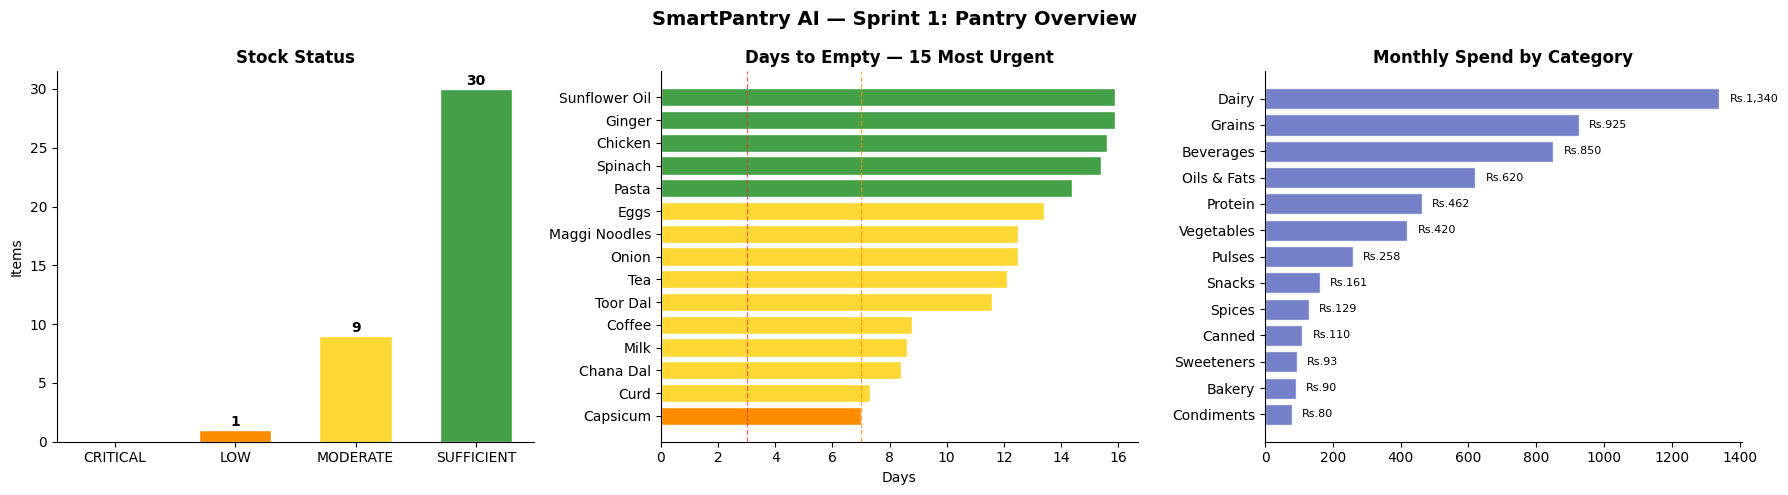

Sprint 1 complete. Chart saved.


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('SmartPantry AI — Sprint 1: Pantry Overview', fontsize=14, fontweight='bold')

ax1 = axes[0]
s_order  = ['CRITICAL','LOW','MODERATE','SUFFICIENT']
s_colors = ['#E53935','#FB8C00','#FDD835','#43A047']
sc2 = df_pantry['stock_status'].value_counts().reindex(s_order, fill_value=0)
bars = ax1.bar(sc2.index, sc2.values, color=s_colors, edgecolor='white', width=0.6)
for bar in bars:
    h = bar.get_height()
    if h > 0: ax1.text(bar.get_x()+bar.get_width()/2, h+.3, str(int(h)), ha='center', fontweight='bold')
ax1.set_title('Stock Status', fontweight='bold'); ax1.set_ylabel('Items')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = axes[1]
urgent = df_pantry.nsmallest(15,'days_to_empty')[['item_name','days_to_empty','stock_status']].copy()
cmap = {'CRITICAL':'#E53935','LOW':'#FB8C00','MODERATE':'#FDD835','SUFFICIENT':'#43A047'}
ax2.barh(urgent['item_name'], urgent['days_to_empty'], color=urgent['stock_status'].map(cmap), edgecolor='white')
ax2.axvline(x=3, color='#E53935', linestyle='--', linewidth=1, alpha=.7)
ax2.axvline(x=7, color='#FB8C00', linestyle='--', linewidth=1, alpha=.7)
ax2.set_title('Days to Empty — 15 Most Urgent', fontweight='bold'); ax2.set_xlabel('Days')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3 = axes[2]
spend_cat = df_pantry.groupby('category')['monthly_spend_inr'].sum().sort_values()
bars3 = ax3.barh(spend_cat.index, spend_cat.values, color='#5C6BC0', edgecolor='white', alpha=.85)
for bar in bars3:
    w = bar.get_width()
    ax3.text(w+30, bar.get_y()+bar.get_height()/2, f'Rs.{int(w):,}', va='center', fontsize=8)
ax3.set_title('Monthly Spend by Category', fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sprint1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sprint 1 complete. Chart saved.')

---
# PART 2 — Sprint 2: Analytics Engine

All dataframes from Part 1 are already in memory. No reload needed.

| Module | What it does |
|---|---|
| Depletion Forecast | Weighted history + menu overlay → urgency score per item |
| Order Optimisation | Budget-constrained priority order list for this week |
| Menu Coverage | Which meals cant be cooked with current stock |
| Spend Analytics | Monthly spend by category vs budget |

---

## Cell 8 — Depletion Forecast

In [51]:
def compute_depletion_forecast(df_pantry, df_history, df_demand):
    df_hist = df_history.copy()
    df_hist['week_start'] = pd.to_datetime(df_hist['week_start'])

    def weighted_avg(grp):
        grp = grp.sort_values('week_start')
        n = len(grp)
        weights = np.array([1]*max(0,n-4) + [2]*min(4,n), dtype=float)[-n:]
        return np.average(grp['consumed_qty'].values, weights=weights)

    hist_rates = (df_hist.groupby('item_name')
        .apply(weighted_avg, include_groups=False)
        .reset_index(name='weighted_weekly_rate'))

    cv_df = (df_hist.groupby('item_name')['consumed_qty']
        .agg(['mean','std'])
        .assign(cv=lambda x: (x['std']/x['mean']*100).round(1))
        .reset_index()[['item_name','cv']])

    df_fc = df_pantry[['item_id','item_name','category','unit','current_stock',
        'daily_consumption_rate','reorder_threshold','lead_time_days',
        'price_inr_per_unit','stock_status','reorder_needed',
        'is_perishable','shelf_life_days']].copy()
    df_fc = df_fc.merge(hist_rates, on='item_name', how='left')
    df_fc = df_fc.merge(cv_df,      on='item_name', how='left')
    df_fc = df_fc.merge(df_demand,  on='item_name', how='left')

    df_fc['weighted_weekly_rate'] = df_fc['weighted_weekly_rate'].fillna(df_fc['daily_consumption_rate']*7)
    df_fc['weekly_menu_demand']   = df_fc['weekly_menu_demand'].fillna(0)
    df_fc['cv']                   = df_fc['cv'].fillna(10)

    df_fc['hist_daily_rate']       = (df_fc['weighted_weekly_rate']/7).round(4)
    df_fc['menu_daily_demand']     = (df_fc['weekly_menu_demand']/7).round(4)
    df_fc['combined_daily_demand'] = df_fc[['hist_daily_rate','menu_daily_demand']].max(axis=1).round(4)
    df_fc['menu_uplift_pct']       = np.where(df_fc['hist_daily_rate']>0,
        ((df_fc['menu_daily_demand']-df_fc['hist_daily_rate'])/df_fc['hist_daily_rate']*100).round(1), 0)
    df_fc['forecast_days_to_empty'] = np.where(df_fc['combined_daily_demand']>0,
        (df_fc['current_stock']/df_fc['combined_daily_demand']).clip(0,60).round(1), 60.0)
    df_fc['urgency_score'] = (
        (1 - df_fc['forecast_days_to_empty'].clip(0,14)/14)*60 +
        (df_fc['cv'].clip(0,30)/30)*20 +
        (df_fc['menu_uplift_pct'].clip(0,100)/100)*20
    ).round(1).clip(0,100)
    df_fc['must_order_by'] = df_fc.apply(
        lambda r: str(today + timedelta(days=max(0, r['forecast_days_to_empty']-r['lead_time_days']-1))), axis=1)
    df_fc['forecast_status'] = pd.cut(df_fc['forecast_days_to_empty'],
        bins=[-1,3,7,14,60], labels=['CRITICAL','LOW','MODERATE','OK'])
    return df_fc.sort_values('urgency_score', ascending=False).reset_index(drop=True)

df_forecast = compute_depletion_forecast(df_pantry, df_history, df_demand)
df_forecast.to_csv(f'{DATA_DIR}/forecast_output.csv', index=False)

sc = df_forecast['forecast_status'].value_counts()
print('Depletion Forecast:')
for s,e in [('CRITICAL','🔴'),('LOW','🟠'),('MODERATE','🟡'),('OK','🟢')]:
    print(f'  {e} {s}: {sc.get(s,0)} items')
print(f'  Menu uplift >20%: {(df_forecast["menu_uplift_pct"]>20).sum()} items')
print()
cols = ['item_name','current_stock','unit','forecast_days_to_empty','urgency_score','must_order_by']
print(df_forecast[cols].head(10).to_string(index=False))
print(f'Saved: {DATA_DIR}/forecast_output.csv')

Depletion Forecast:
  🔴 CRITICAL: 1 items
  🟠 LOW: 7 items
  🟡 MODERATE: 11 items
  🟢 OK: 21 items
  Menu uplift >20%: 15 items

    item_name  current_stock unit  forecast_days_to_empty  urgency_score must_order_by
    Chana Dal           0.14   kg                     2.8           74.2    2026-07-02
     Capsicum           0.93  pcs                     3.3           72.9    2026-07-04
        Onion           1.25   kg                     5.3           65.0    2026-07-06
       Tomato           1.09   kg                     5.3           64.6    2026-07-06
      Chicken           0.78   kg                     5.5           62.8    2026-07-06
Maggi Noodles           1.67 pack                     5.8           60.3    2026-07-05
        Pasta           0.24   kg                     6.7           56.8    2026-07-06
         Eggs          10.75  pcs                     7.5           53.2    2026-07-08
         Poha           0.50   kg                     8.8           49.8    2026-07-08
 

## Cell 9 — Order Optimisation

In [52]:
def build_order_list(df_forecast, monthly_budget_inr, horizon_days=7):
    weekly_budget = monthly_budget_inr / 4
    df = df_forecast.copy()
    df['qty_to_order']   = np.maximum(0, (df['combined_daily_demand']*14) - df['current_stock']).round(2)
    df['order_flag']     = 'SKIP'
    df.loc[df['reorder_needed'] | (df['forecast_days_to_empty']<=horizon_days), 'order_flag'] = 'MUST ORDER'
    df.loc[(df['order_flag']=='SKIP') & (df['urgency_score']>50) & (df['forecast_days_to_empty']<=14), 'order_flag'] = 'RECOMMENDED'
    df['order_cost_inr'] = (df['qty_to_order'] * df['price_inr_per_unit']).round(0)

    candidates = df[df['order_flag'].isin(['MUST ORDER','RECOMMENDED'])].copy()
    candidates = candidates.sort_values(['order_flag','urgency_score'], ascending=[True,False])
    cumulative, selected = 0, []
    for _, row in candidates.iterrows():
        cost = row['order_cost_inr']
        if row['order_flag']=='MUST ORDER':
            selected.append(True); cumulative += cost
        elif cumulative + cost <= weekly_budget:
            selected.append(True); cumulative += cost
        else:
            selected.append(False)
    candidates['within_budget'] = selected
    return candidates[candidates['within_budget']], cumulative, weekly_budget

df_order, total_cost, weekly_budget = build_order_list(df_forecast, family_profile['monthly_grocery_budget_inr'])
df_order.to_csv(f'{DATA_DIR}/order_list.csv', index=False)

must = (df_order['order_flag']=='MUST ORDER').sum()
rec  = (df_order['order_flag']=='RECOMMENDED').sum()
print(f'Order List — Weekly budget: Rs.{weekly_budget:,.0f}')
print(f'  Must order : {must} items')
print(f'  Recommended: {rec} items')
print(f'  Total cost : Rs.{total_cost:,.0f} ({total_cost/weekly_budget*100:.0f}% of budget)')
print()
print(df_order[['item_name','unit','qty_to_order','order_cost_inr','order_flag','urgency_score']].to_string(index=False))
print(f'Saved: {DATA_DIR}/order_list.csv')

Order List — Weekly budget: Rs.3,000
  Must order : 9 items
  Recommended: 1 items
  Total cost : Rs.683 (23% of budget)

    item_name unit  qty_to_order  order_cost_inr  order_flag  urgency_score
    Chana Dal   kg          0.56            50.0  MUST ORDER           74.2
     Capsicum  pcs          3.07            61.0  MUST ORDER           72.9
        Onion   kg          2.05            61.0  MUST ORDER           65.0
       Tomato   kg          1.81            72.0  MUST ORDER           64.6
      Chicken   kg          1.22           220.0  MUST ORDER           62.8
Maggi Noodles pack          2.33            33.0  MUST ORDER           60.3
        Pasta   kg          0.26            21.0  MUST ORDER           56.8
         Curd   kg          0.49            20.0  MUST ORDER           38.1
       Coffee   gm         31.72            71.0  MUST ORDER           25.7
         Eggs  pcs          9.25            74.0 RECOMMENDED           53.2
Saved: /content/SmartPantry-AI/data/order_

## Cell 10 — Menu Coverage Check

In [53]:
def check_menu_coverage(df_forecast, df_demand):
    df = df_demand.merge(
        df_forecast[['item_name','current_stock','unit','forecast_days_to_empty','urgency_score']],
        on='item_name', how='left')
    df['stock_covers_menu'] = df['current_stock'] >= df['weekly_menu_demand']
    df['shortfall']         = (df['weekly_menu_demand'] - df['current_stock']).clip(lower=0).round(3)
    df['coverage_pct']      = (df['current_stock']/df['weekly_menu_demand']*100).clip(0,100).round(1)
    df['risk_level']        = pd.cut(df['coverage_pct'], bins=[-1,50,80,100,101],
                                     labels=['HIGH RISK','MEDIUM RISK','LOW RISK','COVERED'])
    return df.sort_values('coverage_pct').reset_index(drop=True)

df_coverage = check_menu_coverage(df_forecast, df_demand)
df_coverage.to_csv(f'{DATA_DIR}/menu_coverage.csv', index=False)

covered   = df_coverage['stock_covers_menu'].sum()
uncovered = (~df_coverage['stock_covers_menu']).sum()
print(f'Menu Coverage: {covered}/{len(df_coverage)} ingredients covered')
if uncovered > 0:
    print(f'  Gaps ({uncovered} items):')
    print(df_coverage[~df_coverage['stock_covers_menu']][
        ['item_name','unit','weekly_menu_demand','current_stock','shortfall','coverage_pct']
    ].to_string(index=False))
else:
    print('  All ingredients covered!')
print(f'Saved: {DATA_DIR}/menu_coverage.csv')

Menu Coverage: 29/36 ingredients covered
  Gaps (7 items):
    item_name unit  weekly_menu_demand  current_stock  shortfall  coverage_pct
    Chana Dal   kg                0.35           0.14       0.21          40.0
     Capsicum  pcs                2.00           0.93       1.07          46.5
       Tomato   kg                1.45           1.09       0.36          75.2
        Onion   kg                1.65           1.25       0.40          75.8
      Chicken   kg                1.00           0.78       0.22          78.0
Maggi Noodles pack                2.00           1.67       0.33          83.5
        Pasta   kg                0.25           0.24       0.01          96.0
Saved: /content/SmartPantry-AI/data/menu_coverage.csv


## Cell 11 — Spend Analytics

In [54]:
def compute_spend_analytics(df_fc, profile):
    df_sp = df_fc.copy()
    df_sp['monthly_spend_inr'] = (df_sp['combined_daily_demand']*30*df_sp['price_inr_per_unit']).round(0)
    by_cat = df_sp.groupby('category')['monthly_spend_inr'].sum().sort_values(ascending=False)
    total  = by_cat.sum()
    budget = profile['monthly_grocery_budget_inr']
    top5   = df_sp.nlargest(5,'monthly_spend_inr')[['item_name','category','monthly_spend_inr']]
    return {
        'total_monthly_est': round(total,0), 'budget': budget,
        'utilisation_pct': round(total/budget*100,1),
        'budget_headroom': round(budget-total,0),
        'by_category': by_cat.round(0).to_dict(),
        'by_category_pct': (by_cat/total*100).round(1).to_dict(),
        'top5_items': top5.to_dict('records')
    }

spend = compute_spend_analytics(df_forecast, family_profile)
with open(f'{DATA_DIR}/spend_analytics.json','w') as f:
    json.dump(spend, f, indent=2)

print(f'Spend Analytics:')
print(f'  Monthly est  : Rs.{spend["total_monthly_est"]:,.0f}')
print(f'  Budget       : Rs.{spend["budget"]:,}')
print(f'  Utilisation  : {spend["utilisation_pct"]}%')
print(f'  Headroom     : Rs.{spend["budget_headroom"]:,.0f}')
print()
for cat, amt in spend['by_category'].items():
    pct = spend['by_category_pct'][cat]
    bar = chr(9608) * max(1,int(pct/2))
    print(f'  {cat:<18} Rs.{amt:>6,.0f}  ({pct:.0f}%)  {bar}')
print(f'Saved: {DATA_DIR}/spend_analytics.json')

Spend Analytics:
  Monthly est  : Rs.8,304
  Budget       : Rs.12,000
  Utilisation  : 69.2%
  Headroom     : Rs.3,696

  Grains             Rs. 1,846  (22%)  ███████████
  Dairy              Rs. 1,811  (22%)  ██████████
  Protein            Rs. 1,115  (13%)  ██████
  Beverages          Rs.   843  (10%)  █████
  Vegetables         Rs.   806  (10%)  ████
  Oils & Fats        Rs.   647  (8%)  ███
  Pulses             Rs.   409  (5%)  ██
  Snacks             Rs.   228  (3%)  █
  Bakery             Rs.   193  (2%)  █
  Spices             Rs.   129  (2%)  █
  Canned             Rs.   105  (1%)  █
  Sweeteners         Rs.    97  (1%)  █
  Condiments         Rs.    75  (1%)  █
Saved: /content/SmartPantry-AI/data/spend_analytics.json


## Cell 12 — Sprint 2 Dashboard (4 charts)

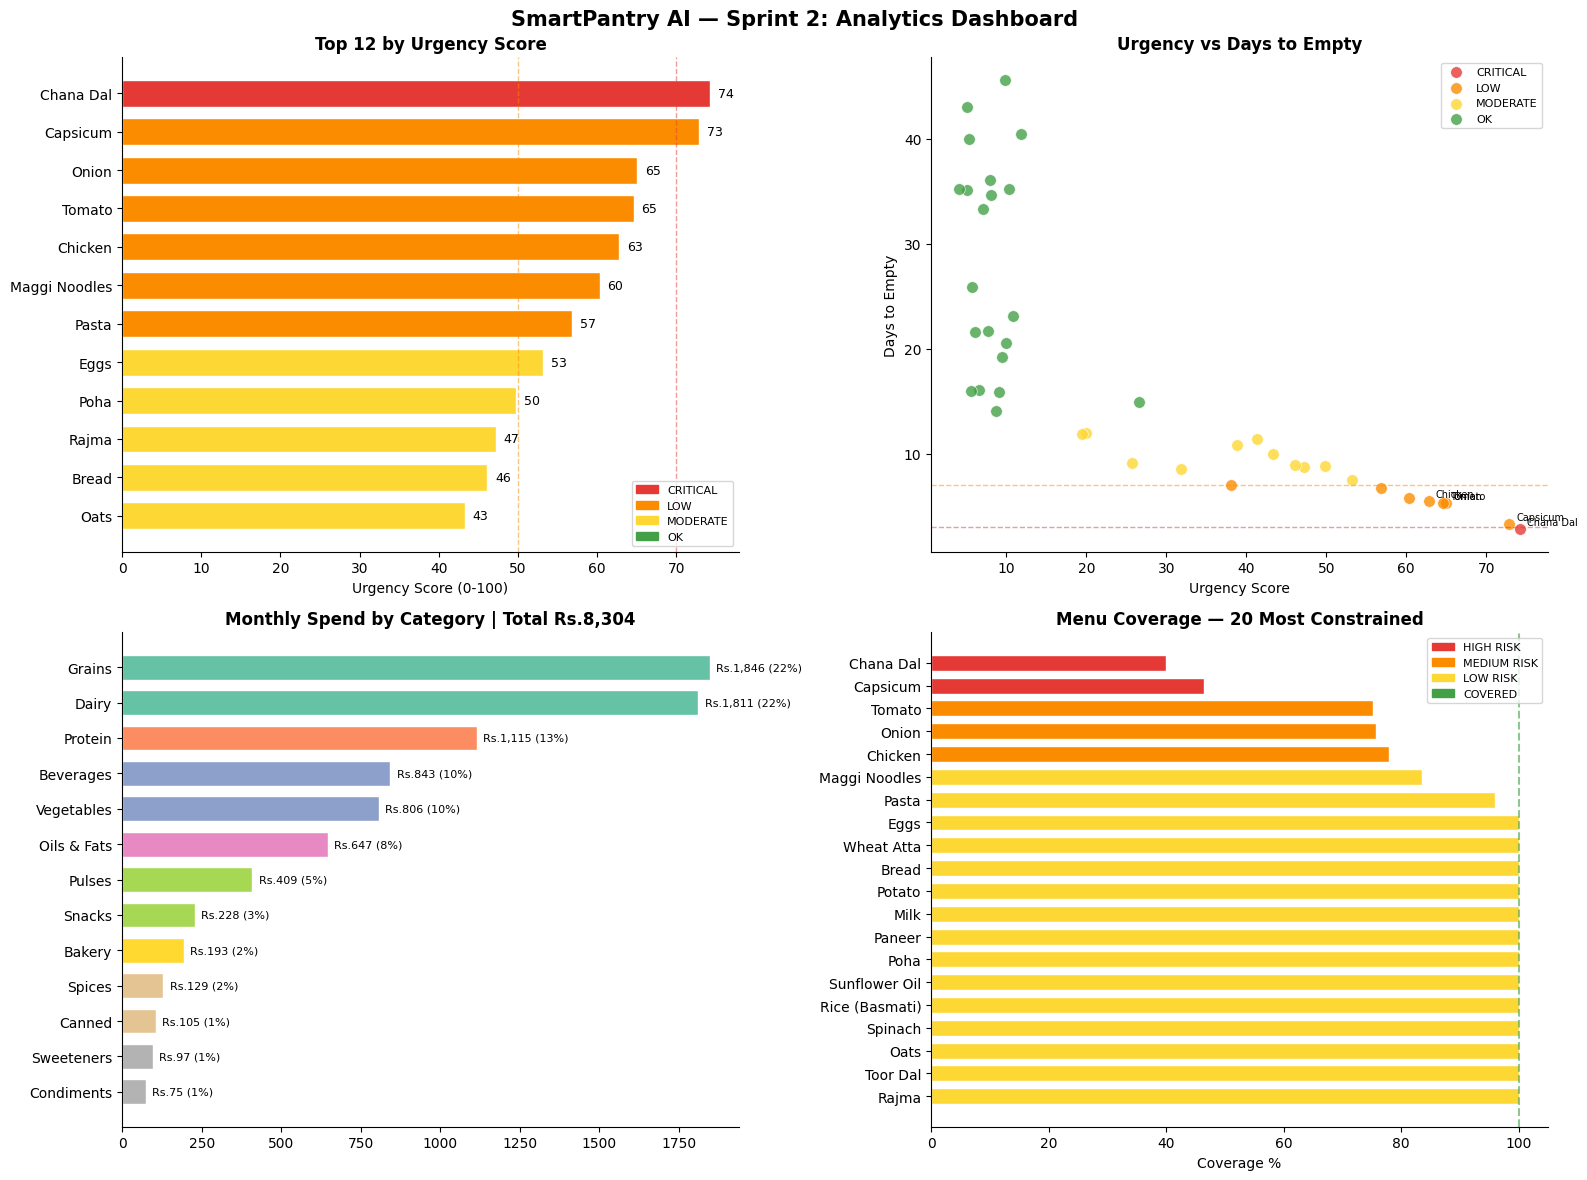

Dashboard saved: /content/SmartPantry-AI/outputs/sprint2_dashboard.png


In [55]:
SC = {'CRITICAL':'#E53935','LOW':'#FB8C00','MODERATE':'#FDD835','OK':'#43A047'}
fig, axes = plt.subplots(2, 2, figsize=(16,12))
fig.suptitle('SmartPantry AI — Sprint 2: Analytics Dashboard', fontsize=15, fontweight='bold')

ax1 = axes[0,0]
top12   = df_forecast.head(12).copy()
bcolors = top12['forecast_status'].astype(str).map(SC).fillna('#90A4AE')
bars    = ax1.barh(top12['item_name'][::-1], top12['urgency_score'][::-1], color=bcolors[::-1], edgecolor='white', height=.7)
ax1.axvline(x=70, color='#E53935', linestyle='--', alpha=.5, linewidth=1)
ax1.axvline(x=50, color='#FB8C00', linestyle='--', alpha=.5, linewidth=1)
for bar in bars:
    w = bar.get_width()
    ax1.text(w+1, bar.get_y()+bar.get_height()/2, f'{w:.0f}', va='center', fontsize=9)
ax1.set_xlabel('Urgency Score (0-100)'); ax1.set_title('Top 12 by Urgency Score', fontweight='bold')
ax1.legend(handles=[mpatches.Patch(color=c,label=s) for s,c in SC.items()], fontsize=8, loc='lower right')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2 = axes[0,1]
for status, color in SC.items():
    mask = df_forecast['forecast_status'].astype(str)==status
    ax2.scatter(df_forecast.loc[mask,'urgency_score'], df_forecast.loc[mask,'forecast_days_to_empty'],
                c=color, label=status, alpha=.8, s=70, edgecolors='white', linewidths=.5)
for _, row in df_forecast.head(5).iterrows():
    ax2.annotate(row['item_name'],(row['urgency_score'],row['forecast_days_to_empty']),fontsize=7,xytext=(5,3),textcoords='offset points')
ax2.axhline(y=7, color='#FB8C00', linestyle='--', alpha=.5, linewidth=1)
ax2.axhline(y=3, color='#E53935', linestyle='--', alpha=.5, linewidth=1)
ax2.set_xlabel('Urgency Score'); ax2.set_ylabel('Days to Empty')
ax2.set_title('Urgency vs Days to Empty', fontweight='bold'); ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3 = axes[1,0]
cats = list(spend['by_category'].keys()); vals = list(spend['by_category'].values())
pcts = list(spend['by_category_pct'].values())
palette = plt.cm.Set2(np.linspace(0,1,len(cats)))
bars3 = ax3.barh(cats[::-1], vals[::-1], color=palette[::-1], edgecolor='white', height=.7)
for bar, pct in zip(bars3, pcts[::-1]):
    w = bar.get_width()
    ax3.text(w+20, bar.get_y()+bar.get_height()/2, f'Rs.{int(w):,} ({pct:.0f}%)', va='center', fontsize=8)
ax3.set_title(f'Monthly Spend by Category | Total Rs.{spend["total_monthly_est"]:,.0f}', fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

ax4 = axes[1,1]
cov20   = df_coverage.head(20).copy()
rmap    = {'HIGH RISK':'#E53935','MEDIUM RISK':'#FB8C00','LOW RISK':'#FDD835','COVERED':'#43A047'}
ccolors = cov20['risk_level'].astype(str).map(rmap).fillna('#90A4AE')
ax4.barh(cov20['item_name'][::-1], cov20['coverage_pct'][::-1], color=ccolors[::-1], edgecolor='white', height=.7)
ax4.axvline(x=100, color='#43A047', linestyle='--', alpha=.6, linewidth=1.5)
ax4.set_xlabel('Coverage %'); ax4.set_title('Menu Coverage — 20 Most Constrained', fontweight='bold')
ax4.legend(handles=[mpatches.Patch(color=c,label=l) for l,c in rmap.items()], fontsize=8)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sprint2_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: {OUTPUT_DIR}/sprint2_dashboard.png')

## Cell 13 — Complete & Save to GitHub

In [56]:
print('=' * 60)
print('  SmartPantry AI — COMPLETE (Sprint 1 + Sprint 2) ')
print('=' * 60)
print()
print('Files created:')
for fname in sorted(os.listdir(DATA_DIR)):
    print(f'  data/{fname}')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  outputs/{fname}')
print()
sc = df_forecast['forecast_status'].value_counts()
print('Key results:')
print(f'  Critical items    : {sc.get("CRITICAL",0)}')
print(f'  Low stock items   : {sc.get("LOW",0)}')
print(f'  Items to order    : {len(df_order)} | Rs.{total_cost:,.0f} this week')
print(f'  Menu gaps         : {(~df_coverage["stock_covers_menu"]).sum()} ingredients short')
print(f'  Monthly spend est : Rs.{spend["total_monthly_est"]:,.0f} / Rs.{spend["budget"]:,} ({spend["utilisation_pct"]}%)')
print()
print('SAVE YOUR WORK:')
print('  File -> Save a copy in GitHub')
print('  Select your SmartPantry-AI repo, add a commit message, click OK')
print()
print('Ready for Sprint 3: Claude API Agent Brain')

  SmartPantry AI — COMPLETE (Sprint 1 + Sprint 2) 

Files created:
  data/.gitkeep
  data/consumption_history.csv
  data/family_profile.json
  data/forecast_output.csv
  data/item_master.csv
  data/menu_coverage.csv
  data/menu_demand.csv
  data/order_list.csv
  data/pantry_snapshot.csv
  data/spend_analytics.json
  data/weekly_menu.csv
  outputs/.gitkeep
  outputs/sprint1_overview.png
  outputs/sprint2_dashboard.png

Key results:
  Critical items    : 1
  Low stock items   : 7
  Items to order    : 10 | Rs.683 this week
  Menu gaps         : 7 ingredients short
  Monthly spend est : Rs.8,304 / Rs.12,000 (69.2%)

SAVE YOUR WORK:
  File -> Save a copy in GitHub
  Select your SmartPantry-AI repo, add a commit message, click OK

Ready for Sprint 3: Claude API Agent Brain
